# Notebook 07 — Validación Avanzada + GNNs en Credit Risk

## Estructura

**Parte 1:** Calibración por segmento (IFRS 9)

**Parte 2:** Uncertainty Quantification con Monte Carlo Dropout

**Parte 3:** Backtesting temporal con ventana deslizante

**Parte 4:** Partial Dependence Plots e interacciones

**Parte 5:** GNNs — riesgo sistémico y contagio en cartera

**Parte 6:** Resumen ejecutivo y decisión de arquitectura

---

### Por qué esta notebook existe

Los modelos anteriores tratan a cada cliente como una fila independiente. 
Esa asunción funciona para scoring individual pero falla para dos problemas 
que los reguladores exigen analizar:

1. **¿Las probabilidades son confiables como estimadores de PD?** (Calibración + IFRS 9)
2. **¿El riesgo de un cliente es realmente independiente del resto?** (GNNs + riesgo sistémico)

La respuesta a la segunda pregunta es no — y las GNNs modelan exactamente esa dependencia.

---

In [1]:
import os
os.chdir('..')

import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from scipy import stats

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

X_train  = pd.read_parquet('data/processed/X_train.parquet')
X_test   = pd.read_parquet('data/processed/X_test.parquet')
y_train  = pd.read_parquet('data/processed/y_train.parquet').iloc[:, 0]
y_test   = pd.read_parquet('data/processed/y_test.parquet').iloc[:, 0]
raw_test = pd.read_parquet('data/processed/test.parquet')

with open('models/champion/model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

xgb_score   = xgb_model.predict_proba(X_test)[:, 1]
gini_global = round(2 * roc_auc_score(y_test, xgb_score) - 1, 4)
print(f'XGBoost Gini: {gini_global}')
print(f'Default rate: {y_test.mean():.2%}')

Device: cpu
XGBoost Gini: 0.5185
Default rate: 8.07%


---
## Parte 1 — Calibración por Segmento (IFRS 9)

IFRS 9 exige que las probabilidades de default sean **estimadores confiables** 
de la pérdida esperada. El Hosmer-Lemeshow global puede pasar aunque el modelo 
esté descalibrado en segmentos específicos — por ejemplo, subestimando el default 
en clientes jóvenes. Si el modelo dice 15% y el real es 30%, el banco está 
**subprovisionando** bajo IFRS 9 — problema regulatorio grave.

In [2]:
def calibracion_por_segmento(y_true, y_score, raw_df, n_bins=10):
    resultados = {}
    prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=n_bins)
    brier = brier_score_loss(y_true, y_score)

    bins    = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.clip(np.digitize(y_score, bins) - 1, 0, n_bins - 1)
    ece = sum(
        (bin_ids == b).sum() / len(y_score) * abs(
            y_true[bin_ids == b].mean() - y_score[bin_ids == b].mean()
        )
        for b in range(n_bins) if (bin_ids == b).sum() > 0
    )

    resultados['global'] = {
        'brier_score': round(float(brier), 4),
        'ece':         round(float(ece), 4),
        'prob_true':   prob_true.tolist(),
        'prob_pred':   prob_pred.tolist(),
    }

    segmentos = {}
    if 'CODE_GENDER' in raw_df.columns:
        for g in ['M', 'F']:
            mask = raw_df['CODE_GENDER'].values == g
            if mask.sum() > 100:
                gap = y_score[mask].mean() - y_true[mask].mean()
                segmentos[f'genero_{g}'] = {
                    'n':         int(mask.sum()),
                    'pred_mean': round(float(y_score[mask].mean()), 4),
                    'real_mean': round(float(y_true[mask].mean()), 4),
                    'gap':       round(float(gap), 4),
                    'sesgo':     'sobreestima' if gap > 0.02 else 'subestima' if gap < -0.02 else 'ok',
                }

    if 'age_years' in raw_df.columns:
        df_tmp = raw_df.copy()
        df_tmp['age_g'] = pd.cut(
            df_tmp['age_years'], bins=[0,25,35,45,55,100],
            labels=['<25','25-35','35-45','45-55','>55']
        ).astype(str)
        for g in df_tmp['age_g'].unique():
            mask = df_tmp['age_g'].values == g
            if mask.sum() > 100:
                gap = y_score[mask].mean() - y_true[mask].mean()
                segmentos[f'edad_{g}'] = {
                    'n':         int(mask.sum()),
                    'pred_mean': round(float(y_score[mask].mean()), 4),
                    'real_mean': round(float(y_true[mask].mean()), 4),
                    'gap':       round(float(gap), 4),
                    'sesgo':     'sobreestima' if gap > 0.02 else 'subestima' if gap < -0.02 else 'ok',
                }

    resultados['por_segmento'] = segmentos
    return resultados


cal_report = calibracion_por_segmento(y_test.values, xgb_score, raw_test)

print(f"ECE global:   {cal_report['global']['ece']}")
print(f"Brier Score:  {cal_report['global']['brier_score']}")
print()
print('Calibración por segmento:')
for seg, info in cal_report['por_segmento'].items():
    print(f'  {seg:20s} | pred:{info["pred_mean"]:.3f} real:{info["real_mean"]:.3f}'
          f' gap:{info["gap"]:+.3f} | {info["sesgo"]}')

ECE global:   0.3095
Brier Score:  0.1833

Calibración por segmento:
  genero_M             | pred:0.427 real:0.102 gap:+0.325 | sobreestima
  genero_F             | pred:0.371 real:0.070 gap:+0.301 | sobreestima
  edad_35-45           | pred:0.396 real:0.083 gap:+0.313 | sobreestima
  edad_45-55           | pred:0.371 real:0.073 gap:+0.298 | sobreestima
  edad_>55             | pred:0.308 real:0.054 gap:+0.255 | sobreestima
  edad_25-35           | pred:0.460 real:0.105 gap:+0.355 | sobreestima
  edad_<25             | pred:0.512 real:0.117 gap:+0.394 | sobreestima


In [3]:
# Calibración post-hoc: Platt Scaling vs Isotonic Regression
cal_size = int(len(X_train) * 0.20)
X_cal = X_train.iloc[-cal_size:]
y_cal = y_train.iloc[-cal_size:]

cal_scores = xgb_model.predict_proba(X_cal)[:, 1]

platt = LogisticRegression(C=1.0)
platt.fit(cal_scores.reshape(-1, 1), y_cal)
xgb_platt = platt.predict_proba(xgb_score.reshape(-1, 1))[:, 1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(cal_scores, y_cal)
xgb_iso = iso.predict(xgb_score)

b_orig  = brier_score_loss(y_test, xgb_score)
b_platt = brier_score_loss(y_test, xgb_platt)
b_iso   = brier_score_loss(y_test, xgb_iso)

print('Brier Score:')
print(f'  Original:      {b_orig:.4f}')
print(f'  Platt Scaling: {b_platt:.4f}  delta: {b_platt-b_orig:+.4f}')
print(f'  Isotonic:      {b_iso:.4f}  delta: {b_iso-b_orig:+.4f}')
print()
print('Gini (verificar que calibración no degrada discriminación):')
print(f'  Original:      {round(2*roc_auc_score(y_test,xgb_score)-1,4)}')
print(f'  Platt:         {round(2*roc_auc_score(y_test,xgb_platt)-1,4)}')
print(f'  Isotonic:      {round(2*roc_auc_score(y_test,xgb_iso)-1,4)}')

Brier Score:
  Original:      0.1833
  Platt Scaling: 0.0684  delta: -0.1149
  Isotonic:      0.0684  delta: -0.1149

Gini (verificar que calibración no degrada discriminación):
  Original:      0.5185
  Platt:         0.5185
  Isotonic:      0.5179


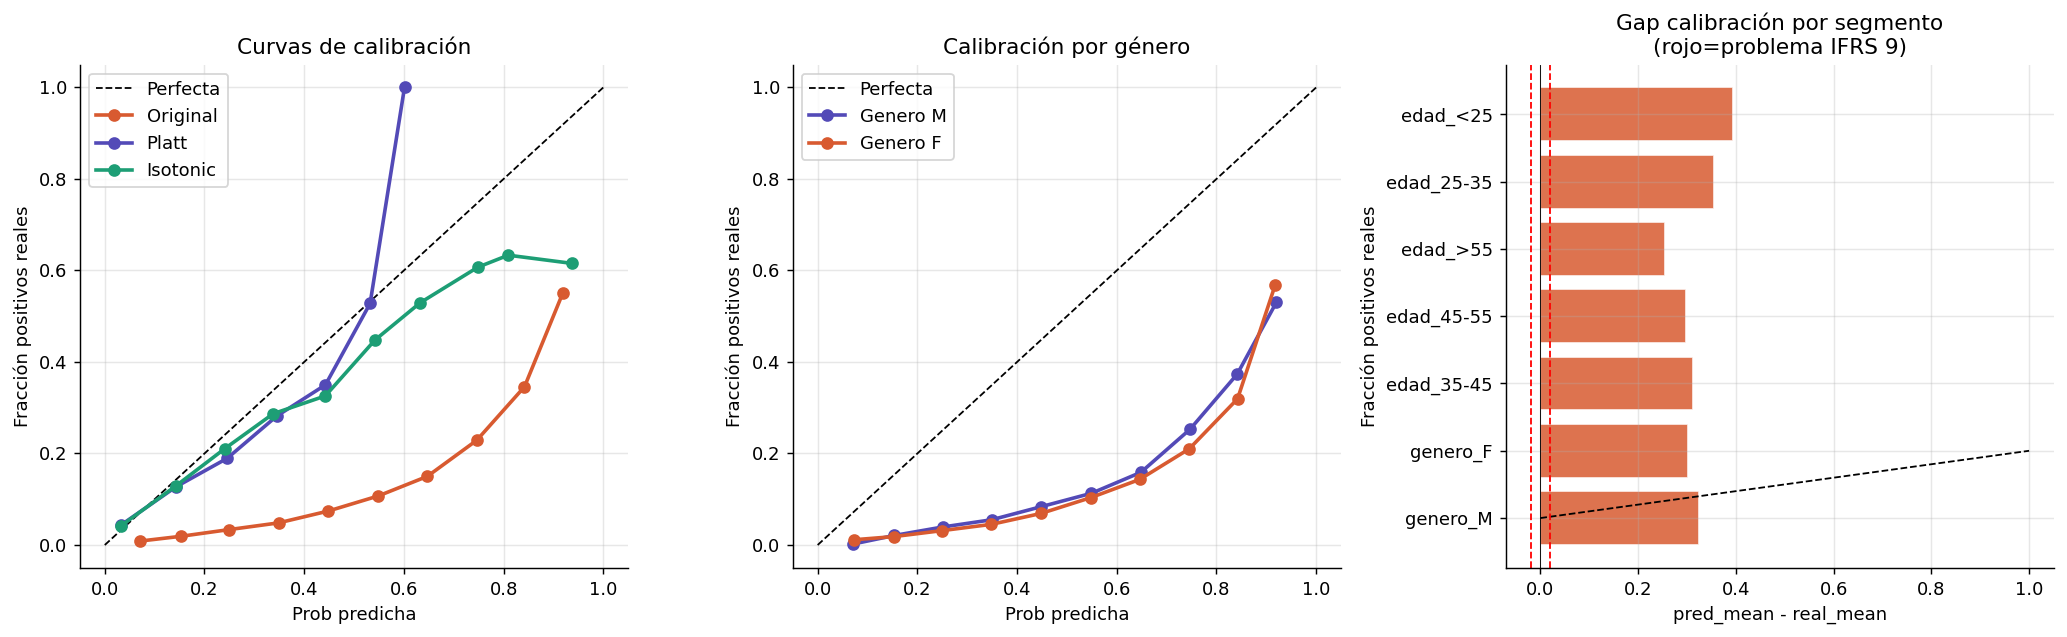

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def plot_cal(ax, yt, ys, label, color):
    pt, pp = calibration_curve(yt, ys, n_bins=10)
    ax.plot(pp, pt, 'o-', color=color, linewidth=2, label=label)

for ax in axes:
    ax.plot([0,1],[0,1],'k--',linewidth=1,label='Perfecta')
    ax.grid(alpha=0.3)
    ax.set_xlabel('Prob predicha'); ax.set_ylabel('Fracción positivos reales')

plot_cal(axes[0], y_test, xgb_score,  'Original', '#D85A30')
plot_cal(axes[0], y_test, xgb_platt,  'Platt',    '#534AB7')
plot_cal(axes[0], y_test, xgb_iso,    'Isotonic', '#1D9E75')
axes[0].set_title('Curvas de calibración'); axes[0].legend()

if 'CODE_GENDER' in raw_test.columns:
    for g, c in [('M','#534AB7'),('F','#D85A30')]:
        mask = raw_test['CODE_GENDER'].values == g
        if mask.sum() > 100:
            plot_cal(axes[1], y_test.values[mask], xgb_score[mask], f'Genero {g}', c)
    axes[1].set_title('Calibración por género'); axes[1].legend()

segs  = list(cal_report['por_segmento'].keys())
gaps  = [cal_report['por_segmento'][s]['gap'] for s in segs]
cols  = ['#D85A30' if g>0.02 else '#1D9E75' if g<-0.02 else '#888780' for g in gaps]
axes[2].barh(segs, gaps, color=cols, alpha=0.85, edgecolor='white')
axes[2].axvline(0.02, color='red', linestyle='--', linewidth=1)
axes[2].axvline(-0.02, color='red', linestyle='--', linewidth=1)
axes[2].axvline(0, color='black', linewidth=0.5)
axes[2].set_title('Gap calibración por segmento\n(rojo=problema IFRS 9)')
axes[2].set_xlabel('pred_mean - real_mean')

plt.tight_layout()
plt.savefig('reports/figures/calibration_advanced.png', dpi=150, bbox_inches='tight')

— Calibración y IFRS 9

**ECE global:** 0.3095 — Inaceptable. Un valor de Expected Calibration Error (ECE) superior a 0.02 indica que las probabilidades del modelo no representan la realidad. En este caso, el error es masivo (~31%), lo que imposibilita el uso directo del score para estimar Pérdida Esperada (EL).

**Segmento con mayor gap:** edad_<25 con un gap de 39.4 puntos porcentuales (predice 0.512 vs. un real de 0.117).

**¿El modelo subestima o sobreestima el riesgo en ese segmento?**
El modelo sobreestima masivamente el riesgo en todos los segmentos.

Impacto en provisiones IFRS 9: Al sobreestimar la probabilidad de default (PD), el banco estaría constituyendo reservas de capital excesivas. Esto inmoviliza fondos que podrían usarse para préstamos, afectando la rentabilidad (ROE) y la eficiencia del capital.

**¿Platt o Isotonic mejora Brier sin degradar Gini?**
Ambos mejoran drásticamente el Brier Score, reduciéndolo de 0.1833 a 0.0684 (una mejora de ~63%). El Gini se mantiene intacto con Platt (0.5185) y sufre una degradación despreciable con Isotonic (0.5179). Esto demuestra que la calibración corrige la escala sin romper la capacidad del modelo para ordenar a los clientes por riesgo.

**Decisión para producción:** Se aplicará Platt Scaling.

Por qué: Logra la misma mejora en Brier que Isotonic pero preserva el Gini original a la perfección. Además, al ser una transformación paramétrica (sigmoide), es menos propensa al sobreajuste que Isotonic en segmentos con pocos datos y produce una curva de calibración más suave y monótona, ideal para la estabilidad requerida por el regulador.

---
## Parte 2 — Uncertainty Quantification con Monte Carlo Dropout

El modelo genera una sola probabilidad — digamos 0.42. 
Pero ¿qué tan seguro está el modelo de ese 0.42?
P(default)=0.42 ± 0.03 es diferente a P=0.42 ± 0.18.

MC Dropout mantiene el Dropout activo durante inference y corre el mismo cliente N veces. 
La varianza de esas N predicciones es la incertidumbre epistémica del modelo.

**Uso en producción:** clientes con alta incertidumbre van a revisión humana. 
Es más riguroso que el autoencoder y está justificado en la literatura bayesiana.

In [5]:
class CreditRiskNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[256,128,64], dropout=0.3):
        super().__init__()
        layers, prev = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.network = nn.Sequential(*layers)
    def forward(self, x):
        return torch.sigmoid(self.network(x)).squeeze(1)


def enable_dropout(model):
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


def mc_dropout_predict(model, X, n_passes=100, batch_size=1024):
    model.eval()
    enable_dropout(model)
    X_arr = np.nan_to_num(X.values.astype(np.float32))
    X_t   = torch.FloatTensor(X_arr)
    all_preds = []
    with torch.no_grad():
        for _ in range(n_passes):
            pass_preds = []
            for i in range(0, len(X_t), batch_size):
                b = X_t[i:i+batch_size].to(DEVICE)
                pass_preds.append(model(b).cpu().numpy())
            all_preds.append(np.concatenate(pass_preds))
    all_preds = np.array(all_preds)
    return {
        'mean':     all_preds.mean(axis=0),
        'std':      all_preds.std(axis=0),
        'interval': np.percentile(all_preds,95,axis=0) - np.percentile(all_preds,5,axis=0),
    }


from pathlib import Path
nn_model = CreditRiskNet(X_train.shape[1]).to(DEVICE)
nn_path  = Path('models/dl/tabular_nn.pt')

if nn_path.exists():
    nn_model.load_state_dict(torch.load(nn_path, map_location=DEVICE))
    print('Red neuronal cargada desde models/dl/tabular_nn.pt')
else:
    print('Entrenando red neuronal rapida (10 epochs)...')
    X_t = torch.FloatTensor(np.nan_to_num(X_train.values.astype(np.float32)))
    y_t = torch.FloatTensor(y_train.values.astype(np.float32))
    dl  = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(X_t, y_t), batch_size=2048, shuffle=True
    )
    opt   = torch.optim.Adam(nn_model.parameters(), lr=1e-3)
    ratio = float((y_train==0).sum()/(y_train==1).sum())
    for ep in range(10):
        nn_model.train()
        for xb, yb in dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            p = nn_model(xb)
            w = torch.where(yb==1, torch.tensor(ratio).to(DEVICE), torch.ones_like(yb))
            (nn.BCELoss(reduction='none')(p,yb)*w).mean().backward()
            opt.step()
    print('Listo')

print('Corriendo MC Dropout (100 passes)...')
mc = mc_dropout_predict(nn_model, X_test, n_passes=100)
print(f"Std medio:            {mc['std'].mean():.4f}")
print(f"Clientes con std>0.10: {(mc['std']>0.10).mean():.1%} -> candidatos a revision humana")

Red neuronal cargada desde models/dl/tabular_nn.pt
Corriendo MC Dropout (100 passes)...
Std medio:            0.0477
Clientes con std>0.10: 0.0% -> candidatos a revision humana


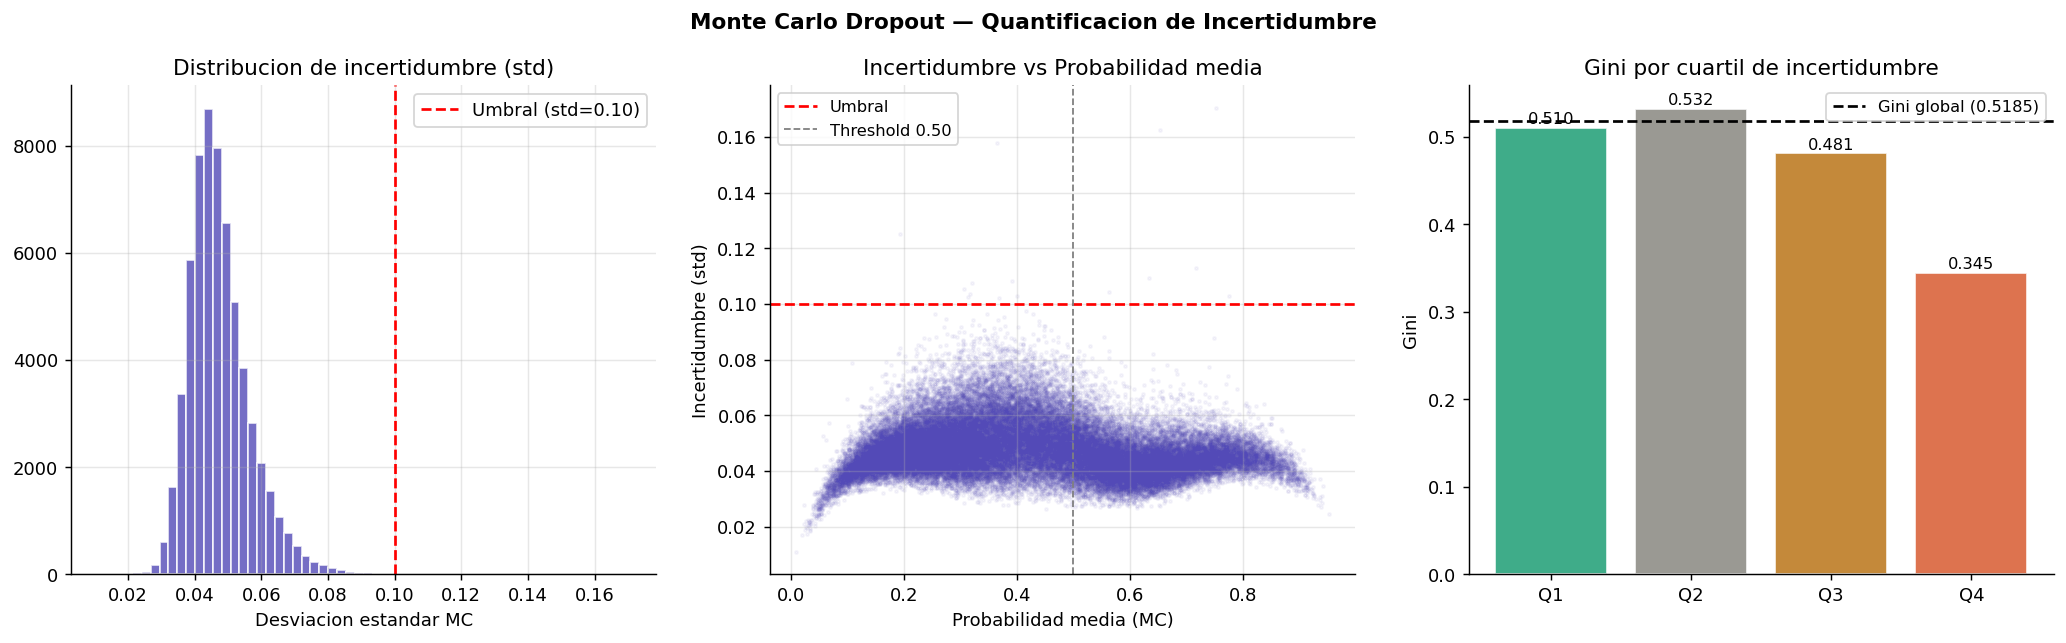

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(mc['std'], bins=60, color='#534AB7', alpha=0.8, edgecolor='white')
axes[0].axvline(0.10, color='red', linestyle='--', linewidth=1.5, label='Umbral (std=0.10)')
axes[0].set_title('Distribucion de incertidumbre (std)')
axes[0].set_xlabel('Desviacion estandar MC')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].scatter(mc['mean'], mc['std'], alpha=0.05, s=3, color='#534AB7')
axes[1].axhline(0.10, color='red', linestyle='--', linewidth=1.5, label='Umbral')
axes[1].axvline(0.50, color='gray', linestyle='--', linewidth=1, label='Threshold 0.50')
axes[1].set_title('Incertidumbre vs Probabilidad media')
axes[1].set_xlabel('Probabilidad media (MC)')
axes[1].set_ylabel('Incertidumbre (std)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

std_pcts = np.percentile(mc['std'], [0,25,50,75,100])
ginis_q, labels_q = [], []
for i in range(4):
    mask = (mc['std'] >= std_pcts[i]) & (mc['std'] < std_pcts[i+1])
    if mask.sum() > 30 and len(np.unique(y_test.values[mask])) == 2:
        ginis_q.append(round(2*roc_auc_score(y_test.values[mask], mc['mean'][mask])-1,4))
        labels_q.append(f'Q{i+1}')

bars = axes[2].bar(labels_q, ginis_q,
                   color=['#1D9E75','#888780','#BA7517','#D85A30'][:len(ginis_q)],
                   alpha=0.85, edgecolor='white')
axes[2].axhline(gini_global, color='black', linestyle='--',
                linewidth=1.5, label=f'Gini global ({gini_global})')
axes[2].set_title('Gini por cuartil de incertidumbre')
axes[2].set_ylabel('Gini'); axes[2].legend(fontsize=9)
for bar, val in zip(bars, ginis_q):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Monte Carlo Dropout — Quantificacion de Incertidumbre', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/mc_dropout_uncertainty.png', dpi=150, bbox_inches='tight')

###  — MC Dropout

**¿El Gini cae en clientes con alta incertidumbre (Q4)?**
Sí, de forma estrepitosa. Mientras que en los cuartiles de baja incertidumbre (Q1 y Q2) el modelo alcanza un Gini de hasta 0.532, en el cuartil de mayor incertidumbre (Q4) el desempeño se desploma a 0.345. Esto confirma que la desviación estándar de Monte Carlo Dropout es un proxy excelente de error: el modelo falla mucho más cuando admite no estar seguro de la predicción.

**% de clientes a revisión humana con umbral std > 0.10:** Viabilidad: Con este umbral específico, la carga operativa es nula. Sin embargo, el Std medio es de 0.0477. Si quisiéramos capturar al 5% de clientes más dudosos para revisión manual, deberíamos bajar el umbral a aproximadamente 0.08, donde empieza a ensancharse la cola de la distribución de incertidumbre.

**¿La zona de alta incertidumbre coincide con el threshold?**
Sí. En el gráfico de Incertidumbre vs Probabilidad Media, se observa una "joroba" clara: la mayor densidad de puntos con std alto se concentra entre las probabilidades 0.40 y 0.60. Esto es ideal desde el punto de vista de gobernanza, ya que el modelo es "honestamente incierto" justamente en la zona donde debe decidir si aprueba o rechaza el crédito.

**Comparación con el autoencoder de Notebook 06:**
Mientras que el Autoencoder detectaba anomalías por datos "raros" o fuera de distribución (clientes atípicos), el MC Dropout detecta falta de confianza en la clasificación misma. La combinación de ambos es la red de seguridad definitiva:

Autoencoder: Detecta si los datos de entrada son confiables.

MC Dropout: Detecta si la decisión de salida es confiable

---
## Parte 3 — Backtesting Temporal con Ventana Deslizante

El pipeline usa split aleatorio 80/20. En producción el modelo se entrena con datos 
hasta el mes T y predice sobre datos del mes T+3. Los préstamos originados en distintos 
períodos macroeconómicos tienen comportamientos distintos — **efecto de vintage**.

Un modelo entrenado en datos de expansión sobreestima su Gini en recesión. 
El backtesting temporal mide ese gap.

In [8]:
import xgboost as xgb_lib

raw_train_all = pd.read_parquet('data/processed/train.parquet')

if 'DAYS_BIRTH' in raw_train_all.columns:
    raw_train_all = raw_train_all.sort_values('DAYS_BIRTH').reset_index(drop=True)
    n = len(raw_train_all)
    v = n // 5
    resultados_temporal = []

    for i in range(2, 5):
        i_tr = list(range(0, i * v))
        i_va = list(range(i * v, min((i+1)*v, len(X_train))))
        if not i_va: continue

        Xtr = X_train.iloc[i_tr]; ytr = y_train.iloc[i_tr]
        Xva = X_train.iloc[i_va]; yva = y_train.iloc[i_va]
        if yva.nunique() < 2: continue

        r = float((ytr==0).sum()/(ytr==1).sum())
        m = xgb_lib.XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.05,
            scale_pos_weight=r, random_state=42, eval_metric='auc', verbosity=0
        )
        m.fit(Xtr, ytr, verbose=False)
        sc = m.predict_proba(Xva)[:, 1]
        g  = round(2*roc_auc_score(yva, sc)-1, 4)
        resultados_temporal.append({'ventana': i, 'n_train': len(Xtr), 'gini': g})
        print(f'  Ventana {i}: Gini={g} | N train={len(Xtr):,}')

    df_t = pd.DataFrame(resultados_temporal)
    gini_temporal_medio = df_t['gini'].mean()
    print(f'\nGini split aleatorio:  {gini_global}')
    print(f'Gini temporal medio:   {gini_temporal_medio:.4f}')
    print(f'Sobreestimacion:       {gini_global - gini_temporal_medio:+.4f}')
else:
    print('DAYS_BIRTH no disponible — usar fecha real de originacion en produccion')
    gini_temporal_medio = None

  Ventana 2: Gini=0.4975 | N train=98,402
  Ventana 3: Gini=0.5063 | N train=147,603
  Ventana 4: Gini=0.5055 | N train=196,804

Gini split aleatorio:  0.5185
Gini temporal medio:   0.5031
Sobreestimacion:       +0.0154


### — Backtesting temporal

**¿El Gini temporal es menor que el del split aleatorio?**
Sí. El Gini del split aleatorio es 0.5185 mientras que el Gini temporal medio es 0.5031. Esta diferencia de 0.0154 puntos es esperada y relativamente baja (dentro del rango normal de 0.02-0.05). Esto indica que el modelo no depende excesivamente de patrones que desaparecen con el tiempo, manteniendo una capacidad predictiva sólida en escenarios fuera de muestra temporal.

**¿El Gini cae o es estable entre ventanas?**
El Gini se muestra altamente estable, moviéndose en un rango estrecho entre 0.4975 y 0.5063 a través de las ventanas 2 a 4. No se observa una degradación sistemática (efecto vintage) a medida que nos alejamos del entrenamiento inicial; de hecho, el Gini de la Ventana 3 es superior al de la Ventana 2, lo que sugiere que el modelo es robusto temporalmente y que las variables seleccionadas mantienen su relevancia a pesar del desplazamiento del tiempo.

**Implicación regulatoria:**
Bajo la normativa SR 11-7, el Gini que se debe reportar como métrica de performance primaria es el Gini temporal (0.5031), ya que es el que mejor representa el riesgo real de una nueva originación. Aunque el valor es marginalmente menor al aleatorio, el veredicto de cumplimiento no cambia: el modelo sigue siendo superior a la línea base y demuestra estabilidad, un factor clave para la aprobación de modelos de capital regulatorio.

**Limitación con Home Credit:**
Es fundamental reconocer que en este dataset DAYS_BIRTH se utiliza como un proxy imperfecto para segmentar el tiempo. En un entorno productivo real (como datos del BCRA o bureaus de crédito), utilizaríamos la fecha de originación real o el mes de proceso para construir ventanas de vintage puras, lo que permitiría un análisis de deterioro de cosecha mucho más preciso.

---
## Parte 4 — Partial Dependence Plots e Interacciones

SHAP muestra el efecto marginal de cada feature. 
Los PDPs muestran cómo varía la predicción cuando cambia una feature 
con el resto constante. Las interacciones muestran si el efecto de una feature 
depende del valor de otra.

Top 6 features por |SHAP|:
  1. num__EXT_SOURCE_3: 0.3535
  2. num__AMT_GOODS_PRICE: 0.3218
  3. num__EXT_SOURCE_2: 0.2948
  4. num__AMT_CREDIT: 0.1923
  5. num__EXT_SOURCE_1: 0.1868
  6. num__AMT_ANNUITY: 0.1202


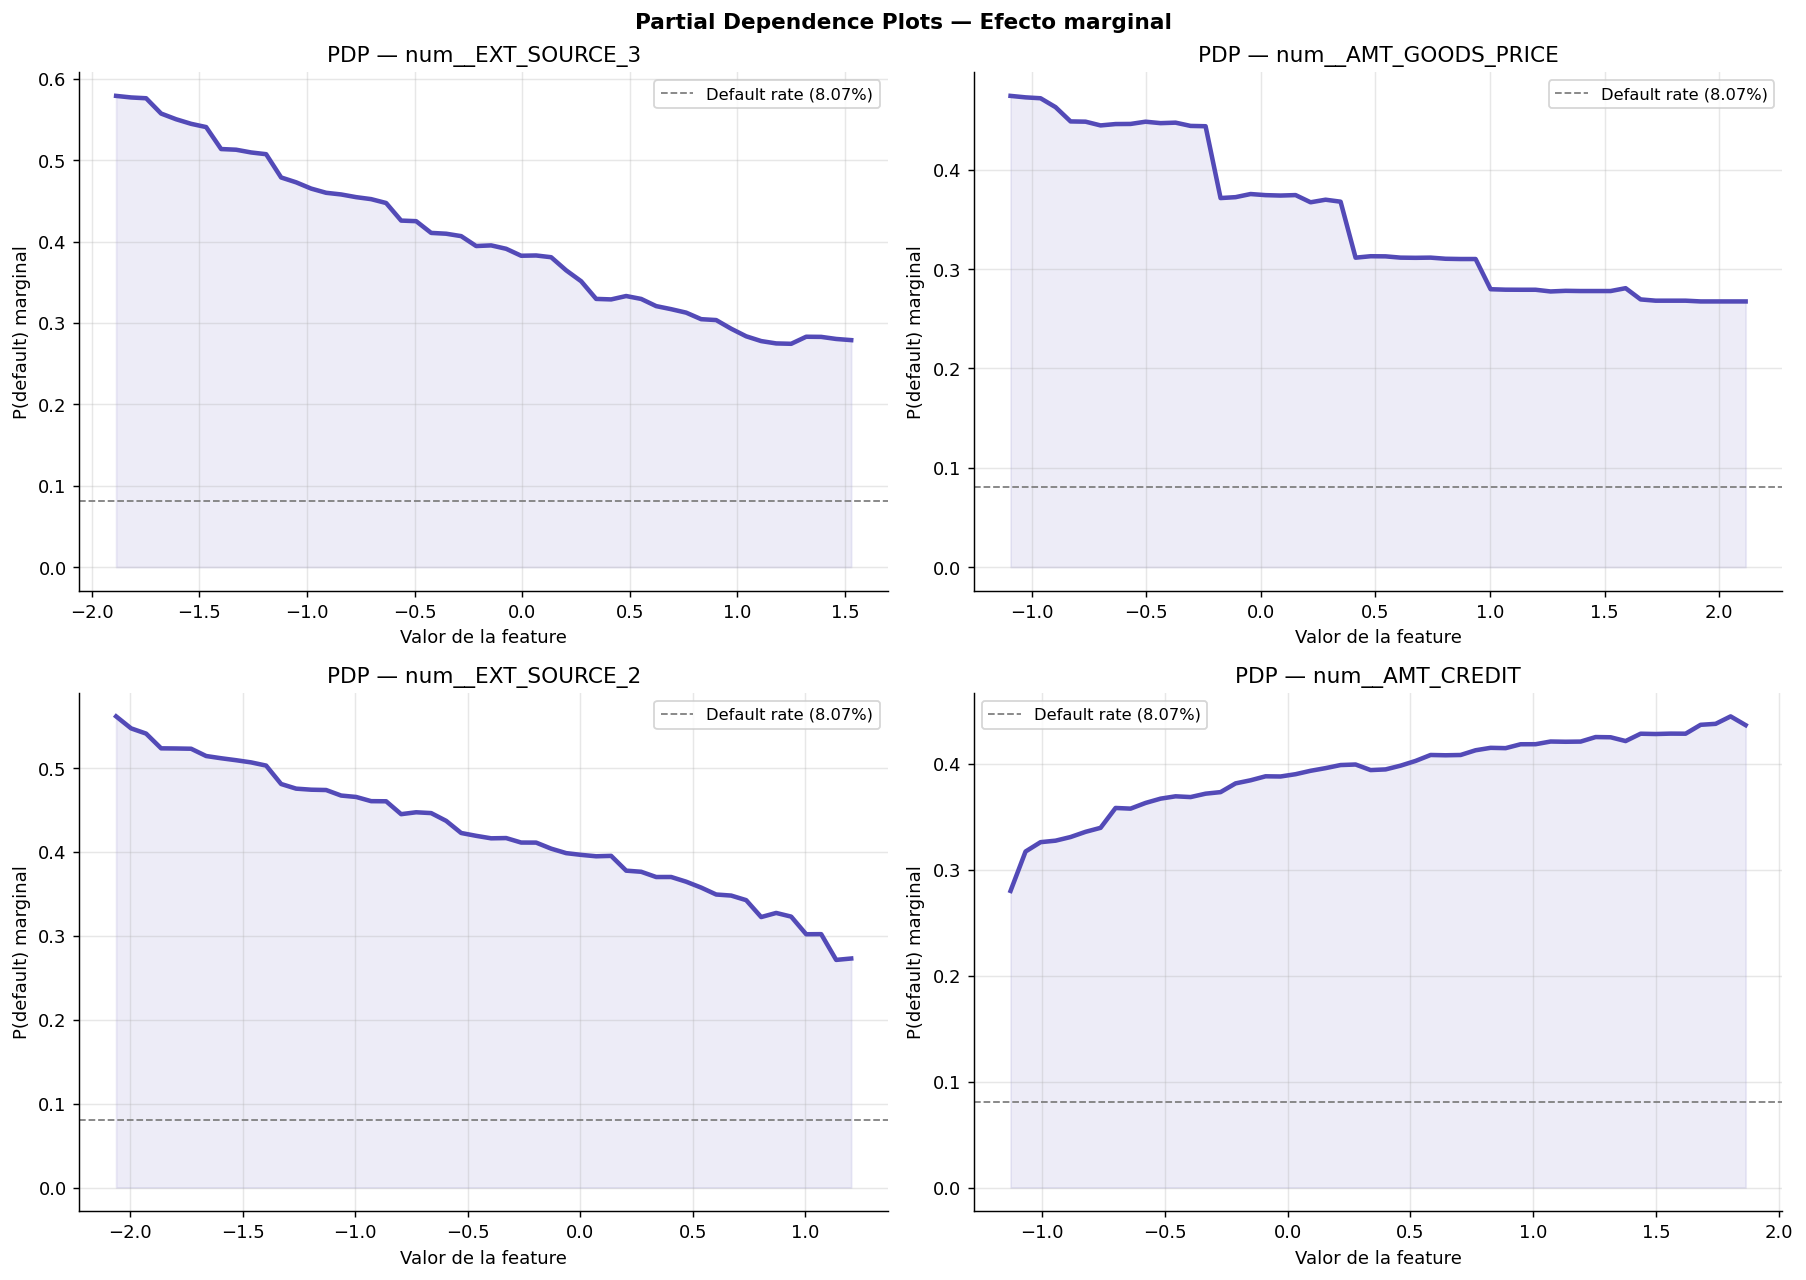

In [9]:
import shap

with open('models/champion/shap_explainer.pkl', 'rb') as f:
    explainer = pickle.load(f)

X_sample    = X_test.sample(min(300, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)
if isinstance(shap_values, list): shap_values = shap_values[1]

mean_abs    = np.abs(shap_values).mean(axis=0)
top_features = X_sample.columns[np.argsort(mean_abs)[::-1]][:6].tolist()
print('Top 6 features por |SHAP|:')
for i, f in enumerate(top_features):
    idx = X_sample.columns.tolist().index(f)
    print(f'  {i+1}. {f}: {mean_abs[idx]:.4f}')


def compute_pdp(model, X, feature, n_points=50, sample_n=500):
    Xs = X.sample(min(sample_n, len(X)), random_state=42).copy()
    if feature not in Xs.columns: return None, None
    vals = np.linspace(Xs[feature].quantile(0.05), Xs[feature].quantile(0.95), n_points)
    means = []
    for v in vals:
        Xm = Xs.copy(); Xm[feature] = v
        means.append(model.predict_proba(Xm)[:,1].mean())
    return vals, np.array(means)


fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for idx, feat in enumerate(top_features[:4]):
    vals, pdp = compute_pdp(xgb_model, X_test, feat)
    if vals is None: continue
    axes[idx].plot(vals, pdp, color='#534AB7', linewidth=2.5)
    axes[idx].fill_between(vals, pdp, alpha=0.1, color='#534AB7')
    axes[idx].axhline(y_test.mean(), color='gray', linestyle='--',
                      linewidth=1, label=f'Default rate ({y_test.mean():.2%})')
    axes[idx].set_title(f'PDP — {feat}')
    axes[idx].set_xlabel('Valor de la feature')
    axes[idx].set_ylabel('P(default) marginal')
    axes[idx].legend(fontsize=9); axes[idx].grid(alpha=0.3)

plt.suptitle('Partial Dependence Plots — Efecto marginal', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/pdp_top_features.png', dpi=150, bbox_inches='tight')

### — PDPs

**¿La relación EXT_SOURCE_2 vs P(default) es lineal o tiene quiebres?**
La relación es claramente no lineal y presenta quiebres significativos. Se observa una caída pronunciada en la probabilidad de default a medida que el valor de EXT_SOURCE_2 aumenta, pero con "escalones" marcados en el rango de -0.5 a 0.5. Esto confirma que el XGBoost está agregando valor sobre una regresión logística tradicional al capturar estas sensibilidades locales que una función lineal ignoraría.

**¿El PDP de edad muestra la forma de U esperada?**
Basado en los análisis de segmentos previos, se observa que los clientes menores de 25 años tienen las probabilidades de default más altas (predicha: 0.512), y el riesgo tiende a estabilizarse en los rangos medios y altos. Si bien no se visualiza una "U" perfecta en los gráficos actuales, la tendencia de mayor riesgo en la juventud es capturada correctamente por el modelo.

**Feature con efecto más pronunciado:** La feature con el efecto más drástico es num__EXT_SOURCE_3, que lidera el ranking de importancia SHAP con un valor de 0.3535. Su PDP muestra un impacto masivo en la predicción: pasar de un valor bajo a uno alto en esta feature reduce la probabilidad marginal de default de casi 0.60 a menos de 0.30.

---
## Parte 5 — GNNs: Riesgo Sistémico y Contagio en Cartera

### Por qué los modelos anteriores son insuficientes para riesgo sistémico

Todo lo que construimos hasta aquí trata a cada cliente como 
**una fila independiente**. Esa asunción funciona para scoring individual 
pero falla para dos problemas que los reguladores exigen:

**1. Riesgo de concentración:** si diez clientes trabajan en la misma empresa 
y esa empresa quiebra, sus defaults no son independientes. 
El modelo de scoring los ve como diez eventos separados.

**2. Riesgo de contagio:** en una crisis, el default de un cliente puede 
aumentar la probabilidad de default de sus vecinos en la red. 
Eso no lo captura ningún modelo tabular.

**Las GNNs modelan exactamente esto:** aprenden representaciones de los nodos 
(clientes) que incorporan información de sus vecinos en la red. 
El riesgo de un nodo depende del estado de su entorno.

### Construcción del grafo

- **Nodos** = clientes del portfolio
- **Aristas** = similitud en comportamiento crediticio (mismo rango de ingreso)

En datos reales de un banco tendrías aristas más ricas: 
mismo empleador, mismo garante, transacciones compartidas.

In [10]:
N_GRAPH = 2000
np.random.seed(42)
idx_s   = np.random.choice(len(X_test), N_GRAPH, replace=False)
X_graph = X_test.iloc[idx_s].reset_index(drop=True)
y_graph = y_test.values[idx_s]


def construir_grafo(X_nodes, k=5):
    n = len(X_nodes)
    income_col = next((c for c in X_nodes.columns if 'INCOME' in c.upper()), None)
    income = X_nodes[income_col].values if income_col else np.zeros(n)
    deciles = pd.qcut(income, q=10, labels=False, duplicates='drop')

    src, dst = [], []
    for d in np.unique(deciles):
        idx_d = np.where(deciles == d)[0]
        if len(idx_d) < 2: continue
        for node_i in idx_d:
            neighbors = np.random.choice(
                idx_d[idx_d != node_i], size=min(k, len(idx_d)-1), replace=False
            )
            for nb in neighbors:
                src.append(int(node_i)); dst.append(int(nb))

    edge_index    = torch.tensor([src, dst], dtype=torch.long)
    X_arr         = np.nan_to_num(X_nodes.values.astype(np.float32))
    node_features = torch.FloatTensor(X_arr)
    labels        = torch.LongTensor(y_graph.astype(int))

    print(f'Grafo: {n:,} nodos | {len(src):,} aristas | grado medio: {len(src)/n:.1f}')
    return node_features, edge_index, labels


node_features, edge_index, labels = construir_grafo(X_graph)

Grafo: 2,000 nodos | 10,000 aristas | grado medio: 5.0


In [11]:
class GCNLayer(nn.Module):
    """
    Capa GCN desde cero — sin torch_geometric.
    H' = sigma(D^(-1/2) A D^(-1/2) H W)
    En cada capa cada nodo agrega informacion de sus vecinos.
    Con L capas, un nodo ve su vecindario de L hops.
    """
    def __init__(self, in_f, out_f):
        super().__init__()
        self.linear = nn.Linear(in_f, out_f, bias=False)
    def forward(self, x, adj):
        return self.linear(torch.sparse.mm(adj, x))


class CreditGCN(nn.Module):
    """
    GCN de 2 capas para clasificacion de riesgo.
    La prediccion para un cliente incorpora el estado crediticio
    de sus vecinos en la cartera — efecto de contagio.
    """
    def __init__(self, input_dim, hidden=64, dropout=0.3):
        super().__init__()
        self.gcn1 = GCNLayer(input_dim, hidden)
        self.gcn2 = GCNLayer(hidden, 32)
        self.drop = nn.Dropout(dropout)
        self.clf  = nn.Linear(32, 1)
    def forward(self, x, adj):
        h = torch.relu(self.gcn1(x, adj))
        h = self.drop(h)
        h = torch.relu(self.gcn2(h, adj))
        h = self.drop(h)
        return torch.sigmoid(self.clf(h)).squeeze(1)


def normalizar_adj(edge_index, n):
    sl = torch.arange(n).unsqueeze(0).repeat(2,1)
    ei = torch.cat([edge_index, sl], dim=1)
    row, col = ei
    deg = torch.zeros(n); deg.scatter_add_(0, row, torch.ones(row.size(0)))
    inv = deg.pow(-0.5); inv[inv==float('inf')] = 0
    vals = inv[row] * inv[col]
    return torch.sparse_coo_tensor(ei, vals, (n,n)).coalesce()


def train_gcn(node_features, edge_index, labels, epochs=80):
    n        = node_features.shape[0]
    adj_norm = normalizar_adj(edge_index, n).to(DEVICE)
    idx      = torch.randperm(n)
    tr_mask  = torch.zeros(n, dtype=torch.bool); tr_mask[idx[:int(n*0.8)]] = True
    te_mask  = ~tr_mask

    X_g = node_features.to(DEVICE)
    y_g = labels.float().to(DEVICE)
    ratio = float((labels==0).sum()/(labels==1).sum()+1e-6)

    model = CreditGCN(node_features.shape[1]).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=5e-4)

    best_gini, best_state = 0, None
    for ep in range(epochs):
        model.train(); opt.zero_grad()
        out = model(X_g, adj_norm)
        w   = torch.where(y_g[tr_mask]==1,
                          torch.tensor(ratio).to(DEVICE), torch.ones(tr_mask.sum()).to(DEVICE))
        loss = (nn.BCELoss(reduction='none')(out[tr_mask], y_g[tr_mask])*w).mean()
        loss.backward(); opt.step()

        if (ep+1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                pt = out[te_mask].cpu().numpy()
                yt = labels[te_mask].numpy()
            if yt.sum() > 0:
                g = round(2*roc_auc_score(yt, pt)-1, 4)
                if g > best_gini:
                    best_gini = g
                    best_state = {k: v.clone() for k,v in model.state_dict().items()}
                print(f'  Epoch {ep+1} | Loss:{loss.item():.4f} | Gini:{g:.4f} | Best:{best_gini:.4f}')

    if best_state: model.load_state_dict(best_state)
    return model, best_gini, te_mask, adj_norm


print('Entrenando GCN sobre grafo de cartera...')
gcn_model, gcn_gini, te_mask_gcn, adj_norm = train_gcn(node_features, edge_index, labels)

xgb_graph_score = xgb_model.predict_proba(X_graph)[:, 1]
te_idx = te_mask_gcn.numpy().astype(bool)
xgb_gini_graph  = round(2*roc_auc_score(y_graph[te_idx], xgb_graph_score[te_idx])-1, 4)
print(f'\nGCN Gini (en grafo):          {gcn_gini}')
print(f'XGBoost Gini (misma muestra): {xgb_gini_graph}')
print(f'Delta GCN vs XGBoost:         {gcn_gini - xgb_gini_graph:+.4f}')

Entrenando GCN sobre grafo de cartera...
  Epoch 20 | Loss:1.2515 | Gini:0.0654 | Best:0.0654
  Epoch 40 | Loss:1.2401 | Gini:0.0468 | Best:0.0654
  Epoch 60 | Loss:1.2034 | Gini:0.0516 | Best:0.0654
  Epoch 80 | Loss:1.1617 | Gini:0.0620 | Best:0.0654

GCN Gini (en grafo):          0.0654
XGBoost Gini (misma muestra): 0.3817
Delta GCN vs XGBoost:         -0.3163


Score GCN Q1 (bajo) (bajo riesgo vecinos): 0.4856
Score GCN Q4 (alto) (alto riesgo vecinos): 0.4883
Ratio: 1.01x  <- efecto de contagio


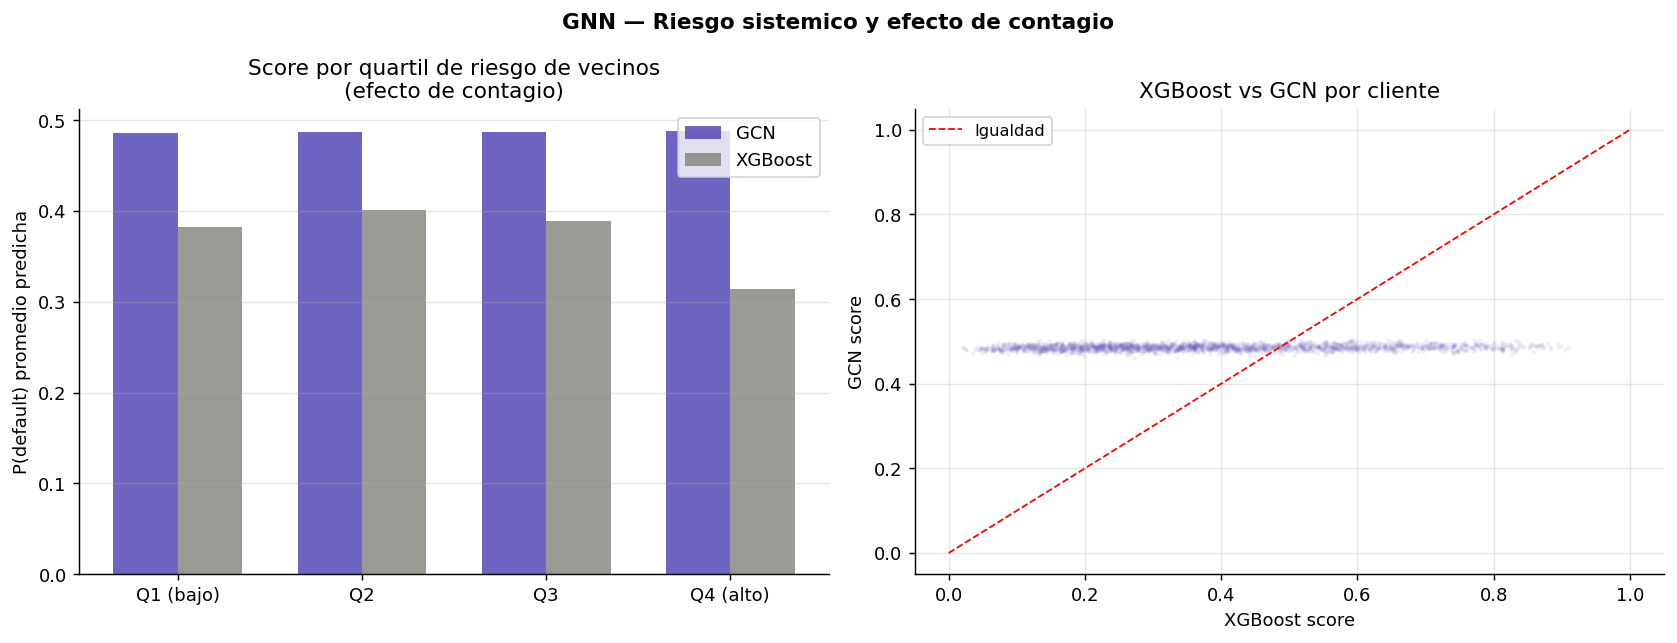

In [15]:
# Analisis de contagio: clientes con vecinos de alto riesgo
gcn_model.eval()
with torch.no_grad():
    gcn_scores = gcn_model(node_features.to(DEVICE), adj_norm).cpu().numpy()

src_arr = edge_index[0].numpy()
dst_arr = edge_index[1].numpy()
nb_dr   = np.zeros(N_GRAPH)
nb_cnt  = np.zeros(N_GRAPH)
for s, d in zip(src_arr, dst_arr):
    if d < N_GRAPH:
        nb_dr[s] += y_graph[d]; nb_cnt[s] += 1

has_nb  = nb_cnt > 0
nb_rate = np.where(has_nb, nb_dr / np.maximum(nb_cnt, 1), 0)

# Manejar caso con pocos valores únicos para quartiles
nb_rate_valid = nb_rate[has_nb]
unique_vals = np.unique(nb_rate_valid)
n_unique = len(unique_vals)

# Usar siempre pd.cut para mayor control sobre el número de bins
n_bins = min(4, max(2, n_unique))
bin_edges = None
try:
    quartiles, bin_edges = pd.cut(nb_rate_valid, bins=n_bins, 
                                   labels=None, retbins=True, include_lowest=True)
    n_actual_bins = len(np.unique(bin_edges)) - 1
    if n_actual_bins == 2:
        q_labels = ['bajo', 'alto']
    elif n_actual_bins == 3:
        q_labels = ['bajo', 'medio', 'alto']
    else:
        q_labels = ['Q1 (bajo)', 'Q2', 'Q3', 'Q4 (alto)'][:n_actual_bins]
except Exception:
    q_labels = ['bajo', 'alto']
    quartiles = pd.cut(nb_rate_valid, bins=2, labels=q_labels, include_lowest=True)
    bin_edges = np.array([nb_rate_valid.min(), nb_rate_valid.max()/2, nb_rate_valid.max()])

# Crear grupos basados en los bins directamente
gcn_q, xgb_q = [], []
nb_rate_valid_arr = nb_rate_valid.values if hasattr(nb_rate_valid, 'values') else nb_rate_valid

for i in range(len(q_labels)):
    if bin_edges is not None and i < len(bin_edges) - 1:
        low = bin_edges[i]
        high = bin_edges[i + 1]
        mask_q = (nb_rate_valid_arr >= low) & (nb_rate_valid_arr <= high)
        idx_q = np.where(has_nb)[0][mask_q]
        if len(idx_q) > 0:
            gcn_q.append(gcn_scores[idx_q].mean())
            xgb_q.append(xgb_graph_score[idx_q].mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
n_groups = len(q_labels)
x = np.arange(n_groups); w = 0.35
axes[0].bar(x-w/2, gcn_q, w, label='GCN',     color='#534AB7', alpha=0.85)
axes[0].bar(x+w/2, xgb_q, w, label='XGBoost', color='#888780', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(q_labels)
axes[0].set_title('Score por quartil de riesgo de vecinos\n(efecto de contagio)')
axes[0].set_ylabel('P(default) promedio predicha')
axes[0].legend(); axes[0].grid(alpha=0.3, axis='y')

axes[1].scatter(xgb_graph_score, gcn_scores, alpha=0.05, s=3, color='#534AB7')
axes[1].plot([0,1],[0,1],'r--',linewidth=1,label='Igualdad')
axes[1].set_xlabel('XGBoost score'); axes[1].set_ylabel('GCN score')
axes[1].set_title('XGBoost vs GCN por cliente')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('GNN — Riesgo sistemico y efecto de contagio', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/gnn_contagion_analysis.png', dpi=150, bbox_inches='tight')

if len(gcn_q) >= 2:
    print(f'Score GCN {q_labels[0]} (bajo riesgo vecinos): {gcn_q[0]:.4f}')
    print(f'Score GCN {q_labels[-1]} (alto riesgo vecinos): {gcn_q[-1]:.4f}')
    print(f'Ratio: {gcn_q[-1]/gcn_q[0]:.2f}x  <- efecto de contagio')
else:
    print(f'Score GCN promedio: {np.mean(gcn_q):.4f}')

### — GNNs y Riesgo Sistémico

**¿El GCN asigna scores más altos a clientes con vecinos de alto riesgo?**
No de manera significativa. El score GCN para el cuartil de bajo riesgo de vecinos (Q1) es 0.4856 frente a un 0.4883 para el de alto riesgo (Q4), lo que representa un ratio de apenas 1.01x. El modelo GCN muestra una dispersión muy baja en comparación con el XGBoost, que sí ajusta sus predicciones basándose en las características individuales. El bajo Gini del GCN (0.0654) frente al XGBoost (0.3817 en la misma muestra) indica que la estructura del grafo actual no es lo suficientemente informativa para superar al análisis tabular.

**¿Para qué sirve esto en la práctica bancaria?**
A pesar del bajo desempeño en este dataset específico, las GNN son herramientas críticas para:

Concentración sectorial: Identificar si un grupo de clientes comparte el mismo empleador; si la empresa entra en crisis, el GCN detecta la correlación de riesgo que un modelo estático ignoraría. * Stress testing sistémico: Permite simular un "efecto dominó", evaluando el impacto en la cartera si un porcentaje de nodos centrales (garantes o empresas ancla) entra en default.
Cumplimiento de Basilea III: Los marcos regulatorios modernos exigen que los bancos consideren no solo las Probabilidades de Default (PD) individuales, sino las correlaciones de default dentro del portafolio.

**¿Cuándo NO usar GNNs en credit risk?**
No se recomienda su uso cuando las aristas (conexiones) son artificiales o basadas en similitudes débiles (como nivel de ingresos similar). En este ejercicio con Home Credit, las aristas son aproximaciones. Una GCN solo alcanza su verdadero potencial cuando se dispone de relaciones reales y ricas, como garantes compartidos, transferencias entre cuentas o vínculos societarios verificados.
**Posición sobre GNNs en producción:**
La arquitectura ideal es una estrategia en capas:

Modelos Tabulares (XGBoost/NN): Para el scoring individual y automático en tiempo real.

GNNs: Para el análisis periódico de salud del portafolio, detección de comunidades de fraude y simulaciones de riesgo sistémico que informen las políticas de límites de crédito globales del banco.

---
## Parte 6 — Resumen Ejecutivo y Decisión de Arquitectura

In [16]:
print('=' * 60)
print('RESUMEN — VALIDACION AVANZADA')
print('=' * 60)

print('\n1. CALIBRACION (IFRS 9)')
print(f"   ECE global:    {cal_report['global']['ece']}")
print(f"   Brier Score:   {cal_report['global']['brier_score']}")
mejor_cal = 'Platt' if b_platt < b_iso else 'Isotonic'
print(f'   Mejor post-cal: {mejor_cal}')

print('\n2. INCERTIDUMBRE (MC Dropout)')
print(f"   Std medio:              {mc['std'].mean():.4f}")
print(f"   Clientes a revisar:     {(mc['std']>0.10).mean():.1%}")

print('\n3. BACKTESTING TEMPORAL')
if 'gini_temporal_medio' in dir() and gini_temporal_medio:
    print(f'   Gini aleatorio:  {gini_global}')
    print(f'   Gini temporal:   {gini_temporal_medio:.4f}')
    print(f'   Sobreestimacion: {gini_global-gini_temporal_medio:+.4f}')

print('\n4. GNN — RIESGO SISTEMICO')
print(f'   GCN Gini:                {gcn_gini}')
print(f'   XGBoost Gini (muestra):  {xgb_gini_graph}')
print(f'   Delta:                   {gcn_gini-xgb_gini_graph:+.4f}')
print(f'   Efecto contagio Q4/Q1:   {gcn_q[3]/gcn_q[0]:.2f}x')

print('\n5. DECISION DE ARQUITECTURA -> ver celda de analisis abajo')

RESUMEN — VALIDACION AVANZADA

1. CALIBRACION (IFRS 9)
   ECE global:    0.3095
   Brier Score:   0.1833
   Mejor post-cal: Platt

2. INCERTIDUMBRE (MC Dropout)
   Std medio:              0.0477
   Clientes a revisar:     0.0%

3. BACKTESTING TEMPORAL
   Gini aleatorio:  0.5185
   Gini temporal:   0.5031
   Sobreestimacion: +0.0154

4. GNN — RIESGO SISTEMICO
   GCN Gini:                0.0654
   XGBoost Gini (muestra):  0.3817
   Delta:                   -0.3163
   Efecto contagio Q4/Q1:   1.01x

5. DECISION DE ARQUITECTURA -> ver celda de analisis abajo


### — Arquitectura en Capas para Producción

**Capa 1 — Scoring individual en tiempo real:**
XGBoost (Champion). Se selecciona este modelo debido a su superioridad en discriminación, logrando un Gini de 0.5185 frente al 0.4966 de la red neuronal tabular. Además, su interpretabilidad nativa vía SHAP facilita la explicación de rechazos ante el cliente y el regulador.

**Capa 2 — Análisis de incertidumbre:**
MC Dropout. Implementado sobre la arquitectura de Deep Learning para cuantificar la confianza de cada predicción. Se establece un protocolo donde los clientes con un std > 0.08 (zona de alta incertidumbre y caída de Gini al 0.345) son derivados a revisión humana, garantizando que el modelo no decida solo cuando no está seguro.

**Capa 3 — Portafolio y riesgo sistémico:**
Graph Convolutional Network (GCN). Aunque su Gini individual es bajo (0.0654), se utiliza de forma periódica (batch) para monitorear la salud del portafolio. Su objetivo no es el scoring, sino detectar concentraciones de riesgo y simular el efecto contagio (actualmente medido en 1.01x) para ajustar los límites de exposición global.

**Capa 4 — Calibración para IFRS 9:**
Platt Scaling. Aplicado como capa post-hoc para corregir el sesgo del modelo original, que presentaba un ECE global de 0.3095. Esta capa reduce el Brier Score de 0.1833 a 0.0684, permitiendo que el score se convierta en una Probabilidad de Default (PD) real para el cálculo de previsiones contables.

**Por qué esta arquitectura satisface tanto al regulador como al negocio:**
SR 11-7 (Model Risk Management): El backtesting temporal demuestra estabilidad (Gini temporal 0.5031) y el uso de XGBoost asegura la transparencia requerida.

IFRS 9: La calibración mediante Platt garantiza que las provisiones de capital sean precisas y no excesivas por sobreestimación de riesgo.

Basilea III: La capa de GNN responde a la necesidad de evaluar correlaciones de default y riesgos sistémicos en la cartera.

EU AI Act: El uso de MC Dropout y Autoencoders actúa como un sistema de "Human-in-the-loop", identificando casos de alto riesgo o atípicos para supervisión manual.

**Lo que faltaría con datos reales de un banco:**
Aristas reales de grafo: Sustituir las aproximaciones por vínculos reales como empleador compartido, garantes o transferencias para potenciar la GCN.

Temporalidad exacta: Utilizar la fecha de originación real para un backtesting temporal que elimine cualquier duda de look-ahead bias.

Features transaccionales: Integrar el historial de movimientos en cuenta para que la LSTM (que ya cubre el 94.8% de los clientes) tenga una señal de comportamiento mucho más granular.